<a href="https://colab.research.google.com/github/vishwajoshi11/vishwajoshi11.github.io/blob/main/Exploratory%20Data%20Analysis%20on%20Telecom%20Customer%20Defection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of data:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovie

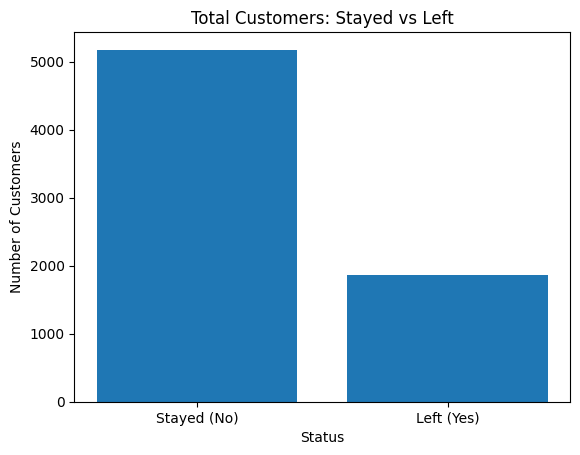

In [1]:
import matplotlib.pyplot as plt
import pandas as pd


data = pd.read_csv("/content/Risk.csv")

# See what the columns look like
print("First 5 rows of data:")
print(data.head())


data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(0)


print("\n--- Churn Count ---")
churn_counts = data["Churn"].value_counts()
print(churn_counts)

total_people = len(data)
left_people = churn_counts["Yes"]
churn_percentage = (left_people / total_people) * 100
print("Churn Percentage:", round(churn_percentage, 2), "%")


people_who_stayed = data[data["Churn"] == "No"]
people_who_left = data[data["Churn"] == "Yes"]

avg_bill_stayed = people_who_stayed["MonthlyCharges"].mean()
avg_bill_left = people_who_left["MonthlyCharges"].mean()

print("\n--- Monthly Charges Comparison ---")
print("Average bill for people who stayed:", round(avg_bill_stayed, 2))
print("Average bill for people who left:", round(avg_bill_left, 2))


plt.bar(["Stayed (No)", "Left (Yes)"], [churn_counts["No"], churn_counts["Yes"]])
plt.title("Total Customers: Stayed vs Left")
plt.xlabel("Status")
plt.ylabel("Number of Customers")

# Save the chart
plt.savefig("simple_churn_chart.png")
print("\nChart saved as 'simple_churn_chart.png'!")
plt.show()